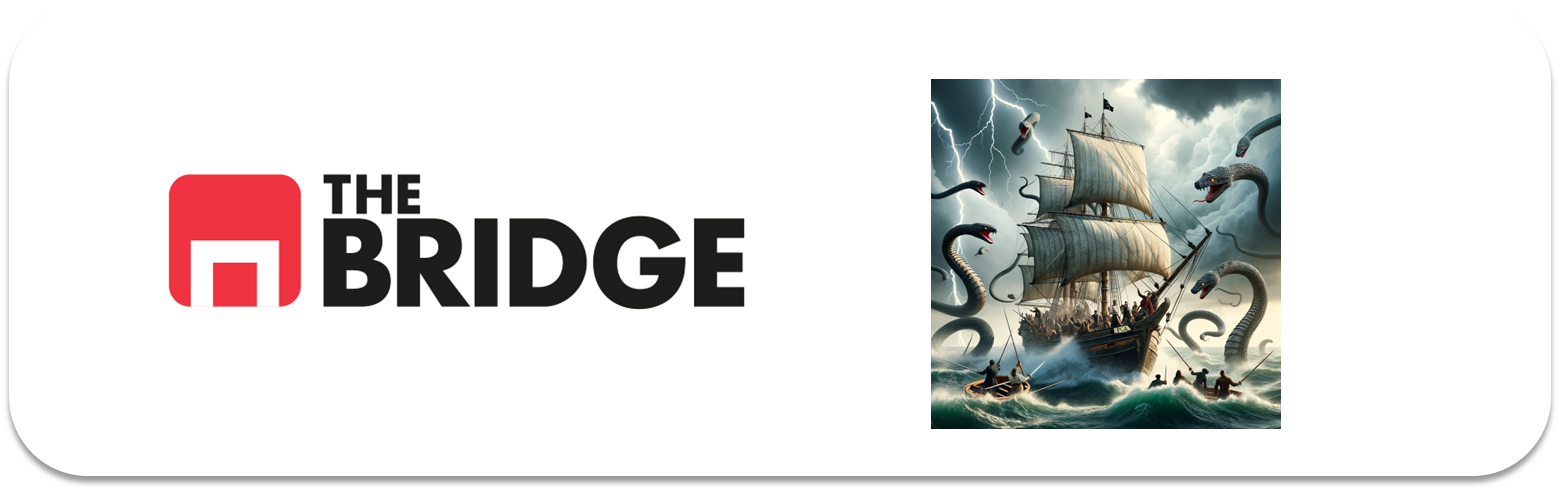

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA

RANDOM_STATE = 42

### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




In [2]:
faces = fetch_olivetti_faces(shuffle=True, random_state=RANDOM_STATE)

X = faces.data
y = faces.target
images = faces.images

print("X:", X.shape)
print("y:", y.shape)
print("images:", images.shape)

X: (400, 4096)
y: (400,)
images: (400, 64, 64)


In [3]:
df_faces = pd.DataFrame(X)
df_faces["target"] = y

df_faces.head()

,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,0.198347,0.235537,0.351240,0.409091,0.421488,0.429752,0.500000,0.528926,0.524793,0.553719,...,0.508264,0.524793,0.504132,0.483471,0.471074,0.285124,0.061983,0.128099,0.090909,20
1,0.185950,0.128099,0.115702,0.132231,0.185950,0.268595,0.433884,0.541322,0.570248,0.586777,...,0.396694,0.409091,0.301653,0.421488,0.462810,0.247934,0.190083,0.210744,0.210744,28
2,0.508264,0.603306,0.619835,0.628099,0.657025,0.665289,0.690083,0.727273,0.743802,0.768595,...,0.301653,0.305785,0.314050,0.326446,0.338843,0.330579,0.334711,0.342975,0.342975,3
3,0.136364,0.140496,0.185950,0.280992,0.318182,0.363636,0.409091,0.417355,0.438017,0.454545,...,0.169421,0.206612,0.276859,0.355372,0.685950,0.661157,0.280992,0.371901,0.276859,21
4,0.652893,0.644628,0.652893,0.706612,0.714876,0.719008,0.743802,0.747934,0.747934,0.756198,...,0.074380,0.074380,0.082645,0.082645,0.111570,0.070248,0.086777,0.185950,0.231405,9


In [4]:
print("Número de imágenes:", X.shape[0])
print("Número de píxeles por imagen:", X.shape[1])
print("Número de clases:", len(np.unique(y)))
print("Valor mínimo de los píxeles:", X.min())
print("Valor máximo de los píxeles:", X.max())

Número de imágenes: 400
Número de píxeles por imagen: 4096
Número de clases: 40
Valor mínimo de los píxeles: 0.0
Valor máximo de los píxeles: 1.0


In [5]:
pd.Series(y).value_counts().sort_index()

0     10
1     10
2     10
3     10
4     10
5     10
6     10
7     10
8     10
9     10
10    10
11    10
12    10
13    10
14    10
15    10
16    10
17    10
18    10
19    10
20    10
21    10
22    10
23    10
24    10
25    10
26    10
27    10
28    10
29    10
30    10
31    10
32    10
33    10
34    10
35    10
36    10
37    10
38    10
39    10
Name: count, dtype: int64

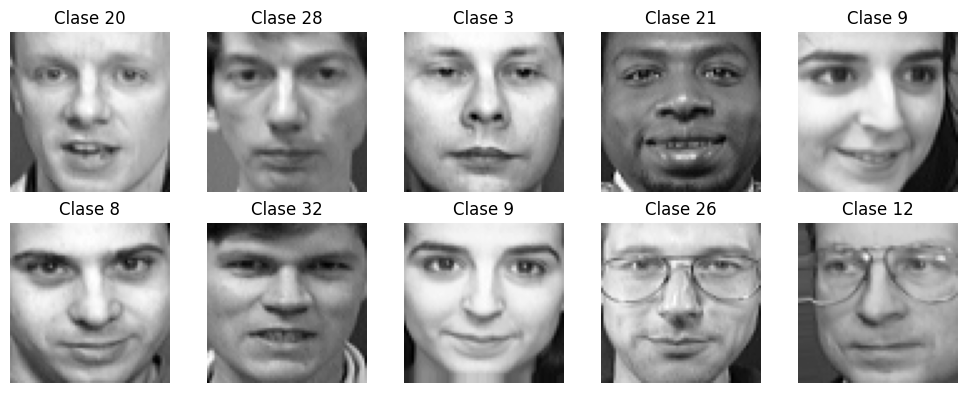

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, img, label in zip(axes.ravel(), images[:10], y[:10]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Clase {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (320, 4096)
X_test: (80, 4096)
y_train: (320,)
y_test: (80,)


In [8]:
base_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [9]:
base_cv_scores = cross_val_score(
    base_model,
    X_train,
    y_train,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1
)

base_cv_score = base_cv_scores.mean()

print("Scores CV:", base_cv_scores)
print("Media CV:", base_cv_score)

Scores CV: [0.9875 0.925  0.9125 0.925  0.875 ]
Media CV: 0.925


In [10]:
base_model.fit(X_train, y_train)

y_pred_base = base_model.predict(X_test)

base_test_score = balanced_accuracy_score(y_test, y_pred_base)

print("Baseline TEST balanced accuracy:", base_test_score)

Baseline TEST balanced accuracy: 0.95


En esta primera parte entrené un modelo usando las imágenes sin comprimir, es decir, con todos los píxeles originales.

El dataset tiene 400 imágenes, cada una con 4096 píxeles, y 40 clases diferentes. Cada clase tiene 10 imágenes, así que está bastante balanceado. También vimos que los valores de los píxeles ya están entre 0 y 1, por lo que no hizo falta hacer una limpieza más profunda.

Después hice el split en train y test de forma estratificada, dejando 320 imágenes para train y 80 para test, como pedía el ejercicio.

El modelo baseline obtuvo un balanced accuracy medio en validación cruzada de 0.925 y un balanced accuracy en test de 0.95.

Estos valores quedan como referencia para comparar después con los modelos usando PCA.

### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

In [11]:
pca_full = PCA()
pca_full.fit(X_train)

print("PCA entrenada con todos los componentes")
print("Número máximo de componentes:", pca_full.n_components_)

PCA entrenada con todos los componentes
Número máximo de componentes: 320


In [12]:
n_features = X_train.shape[1]

componentes_parte_2 = [10, 20, 40, 70, 100]

for n_comp in componentes_parte_2:
    porcentaje = (n_comp / n_features) * 100
    print(n_comp, "componentes =", round(porcentaje, 3), "% del tamaño original")

10 componentes = 0.244 % del tamaño original
20 componentes = 0.488 % del tamaño original
40 componentes = 0.977 % del tamaño original
70 componentes = 1.709 % del tamaño original
100 componentes = 2.441 % del tamaño original


In [13]:
resultados_pca = []

for n_comp in componentes_parte_2:
    
    model_pca = Pipeline([
        ("pca", PCA(n_components=n_comp, random_state=RANDOM_STATE)),
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced"))
    ])
    
    cv_scores = cross_val_score(
        model_pca,
        X_train,
        y_train,
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1
    )
    
    cv_score = cv_scores.mean()
    
    model_pca.fit(X_train, y_train)
    y_pred = model_pca.predict(X_test)
    test_score = balanced_accuracy_score(y_test, y_pred)
    
    porcentaje_compresion = (n_comp / n_features) * 100
    
    resultados_pca.append({
        "n_componentes": n_comp,
        "balanced_accuracy_cv": cv_score,
        "balanced_accuracy_test": test_score,
        "%_tamaño_original": porcentaje_compresion,
        "diferencia_cv_vs_baseline": cv_score - base_cv_score,
        "diferencia_test_vs_baseline": test_score - base_test_score
    })

df_resultados_pca = pd.DataFrame(resultados_pca)

df_resultados_pca

,n_componentes,balanced_accuracy_cv,balanced_accuracy_test,%_tamaño_original,diferencia_cv_vs_baseline,diferencia_test_vs_baseline
0,10,0.8850,0.9250,0.244141,-0.0400,-0.0250
1,20,0.9500,0.9500,0.488281,0.0250,0.0000
2,40,0.9425,0.9875,0.976562,0.0175,0.0375
3,70,0.9525,0.9875,1.708984,0.0275,0.0375
4,100,0.9500,0.9750,2.441406,0.0250,0.0250


In [14]:
candidatos_3 = df_resultados_pca[
    (df_resultados_pca["diferencia_cv_vs_baseline"] >= -0.03) &
    (df_resultados_pca["diferencia_test_vs_baseline"] >= -0.03)
]

elegido_micro = candidatos_3.sort_values("n_componentes").iloc[0]

elegido_micro

n_componentes                  20.000000
balanced_accuracy_cv            0.950000
balanced_accuracy_test          0.950000
%_tamaño_original               0.488281
diferencia_cv_vs_baseline       0.025000
diferencia_test_vs_baseline     0.000000
Name: 1, dtype: float64

En esta parte probé varios modelos usando PCA para comprimir las imágenes antes de clasificarlas.

Probé 10, 20, 40, 70 y 100 componentes, que dejan las imágenes entre un 0.244% y un 2.441% del tamaño original. La idea era encontrar la mayor compresión posible sin perder demasiado rendimiento respecto al modelo baseline.

Con 10 componentes la compresión era muy alta, pero el modelo perdía 4 puntos en validación cruzada, así que no cumple el criterio de perder menos de 3 puntos.

La mejor opción sería usar 20 componentes, porque reduce la imagen a solo un 0.488% del tamaño original y mantiene un balanced accuracy de 0.95 tanto en validación cruzada como en test. Además, no pierde rendimiento en test respecto al baseline.

Por eso, para las microcámaras escogería 20 componentes PCA.

### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

In [15]:
componentes_parte_3 = [4, 8, 16, 24, 40]

for n_comp in componentes_parte_3:
    porcentaje = (n_comp / n_features) * 100
    print(n_comp, "componentes =", round(porcentaje, 3), "% del tamaño original")

4 componentes = 0.098 % del tamaño original
8 componentes = 0.195 % del tamaño original
16 componentes = 0.391 % del tamaño original
24 componentes = 0.586 % del tamaño original
40 componentes = 0.977 % del tamaño original


In [ ]:
componentes_parte_3 = [5, 8, 16, 24, 40]

resultados_unzip = []

for n_comp in componentes_parte_3:
    
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    
    X_train_zip = pca.fit_transform(X_train)
    X_test_zip = pca.transform(X_test)
    
    X_train_unzip = pca.inverse_transform(X_train_zip)
    X_test_unzip = pca.inverse_transform(X_test_zip)
    
    model_unzip = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced"))
    ])
    
    model_unzip.fit(X_train_unzip, y_train)
    y_pred_unzip = model_unzip.predict(X_test_unzip)
    
    test_score_unzip = balanced_accuracy_score(y_test, y_pred_unzip)
    
    porcentaje_compresion = (n_comp / n_features) * 100
    
    resultados_unzip.append({
        "n_componentes": n_comp,
        "balanced_accuracy_test": test_score_unzip,
        "%_tamaño_original": porcentaje_compresion,
        "diferencia_test_vs_baseline": test_score_unzip - base_test_score
    })

df_resultados_unzip = pd.DataFrame(resultados_unzip)

df_resultados_unzip

,n_componentes,balanced_accuracy_test,%_tamaño_original,diferencia_test_vs_baseline
0,5,0.7750,0.122070,-0.1750
1,8,0.9000,0.195312,-0.0500
2,16,0.9500,0.390625,0.0000
3,24,0.9625,0.585938,0.0125
4,40,0.9625,0.976562,0.0125


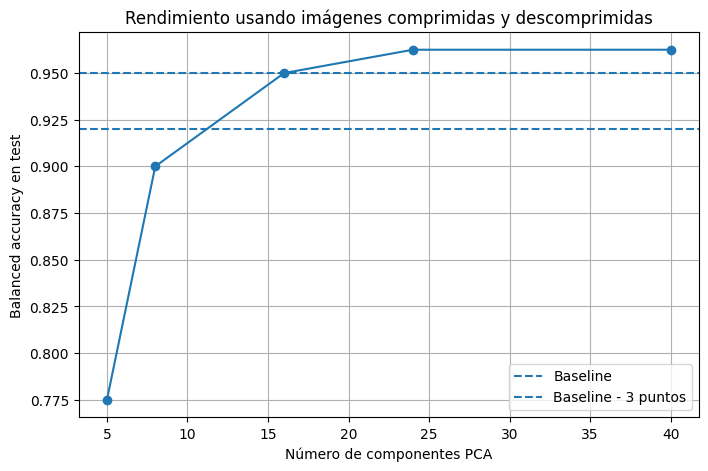

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_unzip["n_componentes"],
    df_resultados_unzip["balanced_accuracy_test"],
    marker="o"
)

plt.axhline(base_test_score, linestyle="--", label="Baseline")
plt.axhline(base_test_score - 0.03, linestyle="--", label="Baseline - 3 puntos")

plt.xlabel("Número de componentes PCA")
plt.ylabel("Balanced accuracy en test")
plt.title("Rendimiento usando imágenes comprimidas y descomprimidas")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
candidatos_unzip = df_resultados_unzip[
    df_resultados_unzip["diferencia_test_vs_baseline"] >= -0.03
]

elegido_servidor = candidatos_unzip.sort_values("n_componentes").iloc[0]

elegido_servidor

n_componentes                  16.000000
balanced_accuracy_test          0.950000
%_tamaño_original               0.390625
diferencia_test_vs_baseline     0.000000
Name: 2, dtype: float64

En esta parte probé otra estrategia: primero comprimir las imágenes con PCA, después reconstruirlas con inverse_transform y finalmente entrenar el modelo con esas imágenes descomprimidas.

Probé 5, 8, 16, 24 y 40 componentes. Con 5 componentes el rendimiento bajaba mucho, y con 8 componentes todavía se perdían 5 puntos respecto al baseline, así que no cumplía el criterio de perder menos de 3 puntos.

La mejor opción sería usar 16 componentes, porque reduce la imagen a un 0.390% del tamaño original y mantiene un balanced accuracy en test de 0.95, igual que el modelo baseline.

Por eso, para la opción de enviar las imágenes comprimidas al servidor central y reconstruirlas allí, escogería 16 componentes PCA.

### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.

In [19]:
def ver_reconstruccion(n_componentes, indices=[0, 1, 2, 3, 4]):
    
    pca = PCA(n_components=n_componentes, random_state=RANDOM_STATE)
    
    X_train_zip = pca.fit_transform(X_train)
    X_train_unzip = pca.inverse_transform(X_train_zip)
    
    fig, axes = plt.subplots(len(indices), 2, figsize=(5, 10))
    
    fig.suptitle(f"Reconstrucción con {n_componentes} componentes", fontsize=14)
    
    for i, idx in enumerate(indices):
        axes[i, 0].imshow(X_train[idx].reshape(64, 64), cmap="gray")
        axes[i, 0].set_title("Original")
        axes[i, 0].axis("off")
        
        axes[i, 1].imshow(X_train_unzip[idx].reshape(64, 64), cmap="gray")
        axes[i, 1].set_title("Reconstruida")
        axes[i, 1].axis("off")
    
    plt.tight_layout()
    plt.show()

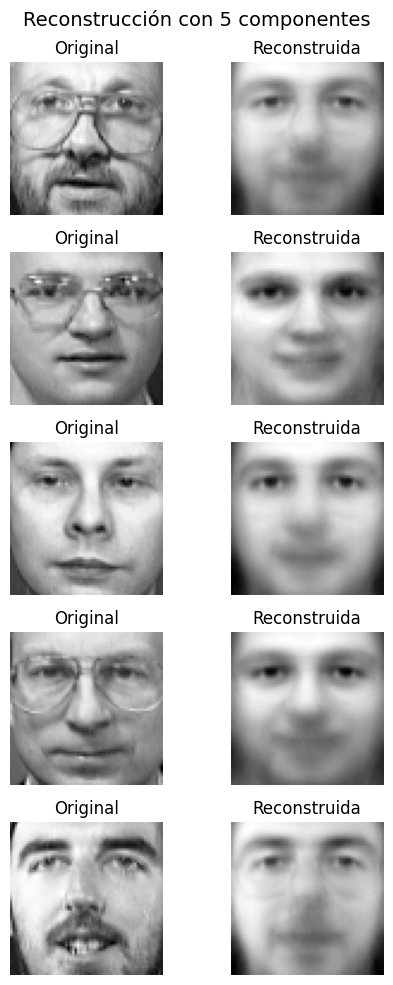

In [20]:
ver_reconstruccion(5)

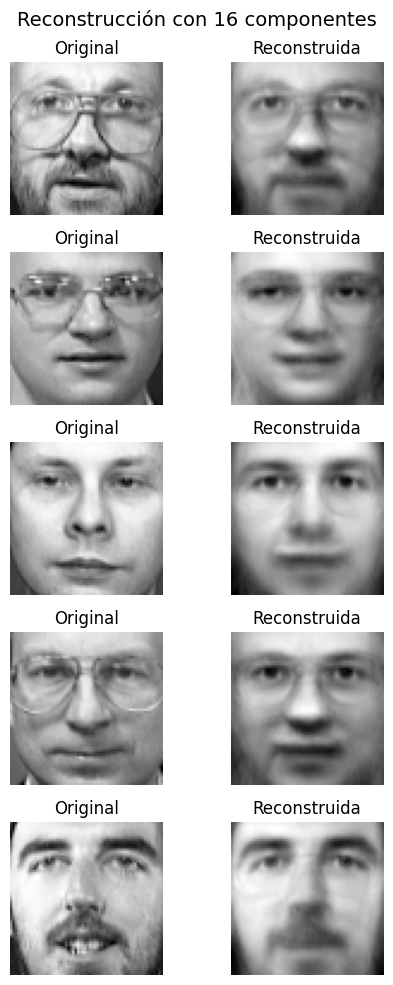

In [21]:
ver_reconstruccion(16)

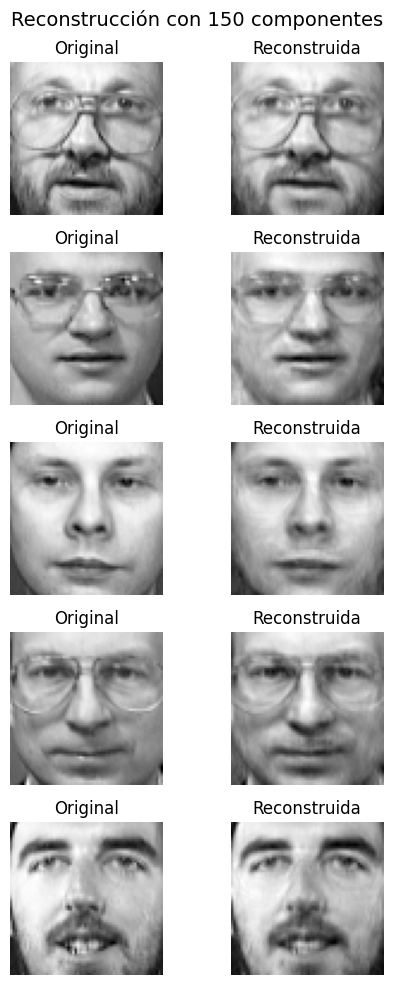

In [22]:
ver_reconstruccion(150)

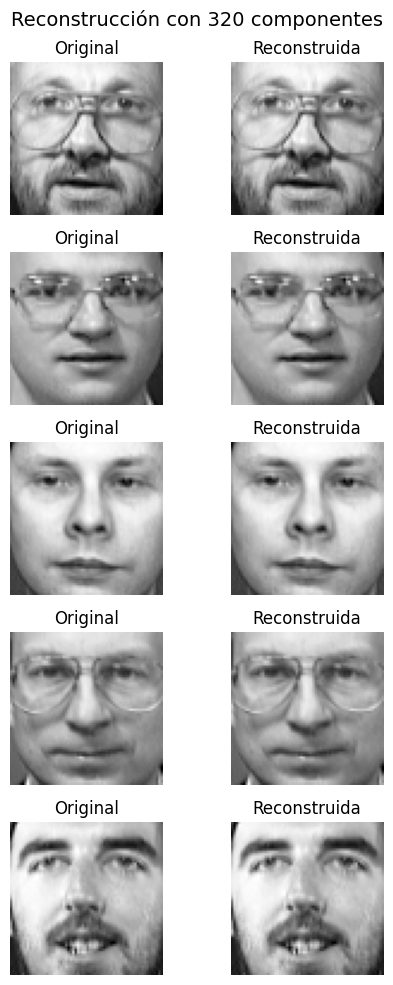

In [23]:
ver_reconstruccion(320)

Para comprobar cómo afecta la compresión con PCA, comparé algunas imágenes originales con sus versiones reconstruidas usando inverse_transform.

Con 5 componentes, las imágenes quedan muy borrosas y se pierde mucho detalle. Con 16 componentes, que fue el valor elegido en la parte anterior, las caras siguen algo borrosas, pero ya se reconocen mucho mejor. Con 150 componentes la reconstrucción mejora bastante, y con 320 componentes la imagen reconstruida es casi igual a la original.

Esto muestra que, al aumentar el número de componentes PCA, se conserva más información de la imagen, aunque también se reduce menos el tamaño.